### In this notebook, we will learn to use PCA to reduce the dimensionality of the dataset along with preserving maximum information our dataset originally holds.
- This dataset is a classification type dataset having 784 Features each having the info of 1 pixel of the image in binary(0,1).
- This dataset has the info of the digits in the 28x28 pixels format 
- Target column named(label) tells us to what data of digit each row holds. There are total 42000 rows.

In [12]:
# plt.style.available

In [13]:
# importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")

In [6]:
#importing the dataset
df = pd.read_csv('train.csv')
print(df.head())

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

In [7]:
# Basic info about the columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [8]:
# basic stats 
print(df.describe())

              label   pixel0   pixel1   pixel2   pixel3   pixel4   pixel5  \
count  42000.000000  42000.0  42000.0  42000.0  42000.0  42000.0  42000.0   
mean       4.456643      0.0      0.0      0.0      0.0      0.0      0.0   
std        2.887730      0.0      0.0      0.0      0.0      0.0      0.0   
min        0.000000      0.0      0.0      0.0      0.0      0.0      0.0   
25%        2.000000      0.0      0.0      0.0      0.0      0.0      0.0   
50%        4.000000      0.0      0.0      0.0      0.0      0.0      0.0   
75%        7.000000      0.0      0.0      0.0      0.0      0.0      0.0   
max        9.000000      0.0      0.0      0.0      0.0      0.0      0.0   

        pixel6   pixel7   pixel8  ...      pixel774      pixel775  \
count  42000.0  42000.0  42000.0  ...  42000.000000  42000.000000   
mean       0.0      0.0      0.0  ...      0.219286      0.117095   
std        0.0      0.0      0.0  ...      6.312890      4.633819   
min        0.0      0.0      0

In [20]:
df.isnull().sum().sum() # This shows there are no null values in entire dataset

np.int64(0)

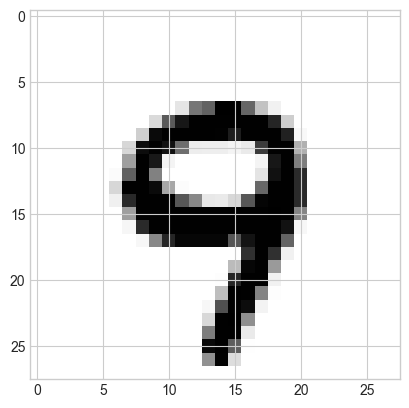

In [ ]:
# Let us see how the image is formed by using the columns as one pixel each
plt.imshow(df.iloc[11111,1:].values.reshape(28,28)) # see this row contains the info of Number 9

In [ ]:
# Let us look at the distribution of Target variable
(df['label'].value_counts()/42000)*100 # we see that the distribution is almost even

label
1    11.152381
7    10.478571
3    10.359524
9     9.971429
2     9.945238
6     9.850000
0     9.838095
4     9.695238
8     9.673810
5     9.035714
Name: count, dtype: float64

<Axes: xlabel='label'>

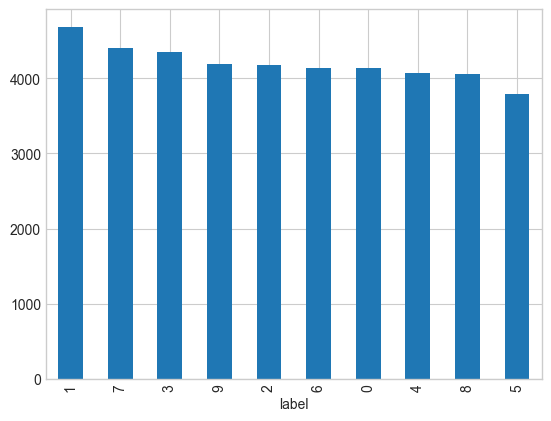

In [ ]:
df['label'].value_counts().plot(kind='bar') 

### There is no uneven distribution b/w the categories

### Firstly train the classification model without using PCA and check the accuracy score

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score , StratifiedKFold

# prepare the data by splitting features and Target data
X = df.iloc[:,1:]
y = df.iloc[:,0]

print(X.shape)
print(y.shape)

(42000, 784)
(42000,)


In [34]:
# using cross-validation with stratify
knn = KNeighborsClassifier()
cv = StratifiedKFold(n_splits=5 , shuffle=True , random_state=42)
scores = cross_val_score(knn , X,y ,scoring='accuracy' , cv = cv)

print('Scores After 5 fold cross-validation with Stratify\n{scores}')

Scores After 5 fold cross-validation with Stratify
{scores}


In [ ]:
print(np.mean(scores)) # So we are getting mean score of 96.69% which is actually great!!

0.966952380952381


### ***Performing Dimensionality Reduction using PCA***